In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

RANDOM_SEED = 42

# Chebyshev points

In [2]:
def chebyshev(N):
  """
  generating N chebyshev node, range => [-1,1]
  """
  k = np.arange(0,N)
  x = np.cos(np.pi*k/N)
  return x

In [3]:
N = 15

x_uniform = np.linspace(-1,1,N)
x_chebyshev = chebyshev(N)

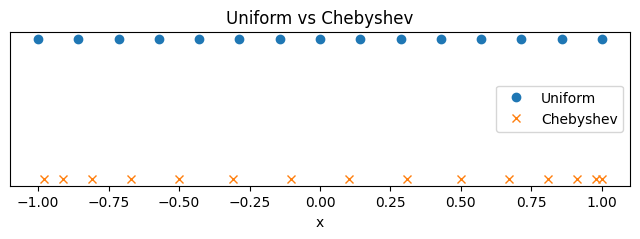

In [4]:
plt.figure(figsize=(8,2))
plt.plot(x_uniform, np.ones_like(x_uniform),'o',label="Uniform")
plt.plot(x_chebyshev, np.zeros_like(x_chebyshev),'x',label="Chebyshev")

plt.yticks([])
plt.xlabel('x')
plt.legend()
plt.title("Uniform vs Chebyshev")
plt.show()

## Why do Chebyshev points represent smooth functions better than uniform points, especially near boundaries?

Let's take an example function and observe!

$$f(x)=1/(1+25x^2)$$

In [5]:
def f(x):
  return 1/(1+25*x**2)

In [6]:
f_uniform = f(x_uniform)
f_chebyshev = f(x_chebyshev)

In [7]:
## creating fine-grid
x_fine = np.linspace(-1,1,1000)
f_fine = f(x_fine)

## Interpolating the sampled points to the functions

In [8]:
# polynomial interpolation
p_uniform = np.polyfit(x_uniform, f_uniform, N)
p_cheb = np.polyfit(x_chebyshev, f_chebyshev, N)

/tmp/ipykernel_55/287365959.py:2: RankWarning: Polyfit may be poorly conditioned
  p_uniform = np.polyfit(x_uniform, f_uniform, N)
/tmp/ipykernel_55/287365959.py:3: RankWarning: Polyfit may be poorly conditioned
  p_cheb = np.polyfit(x_chebyshev, f_chebyshev, N)


In [9]:
# evaluate interpolants
f_uniform_interp = np.polyval(p_uniform, x_fine)
f_cheb_interp = np.polyval(p_cheb, x_fine)

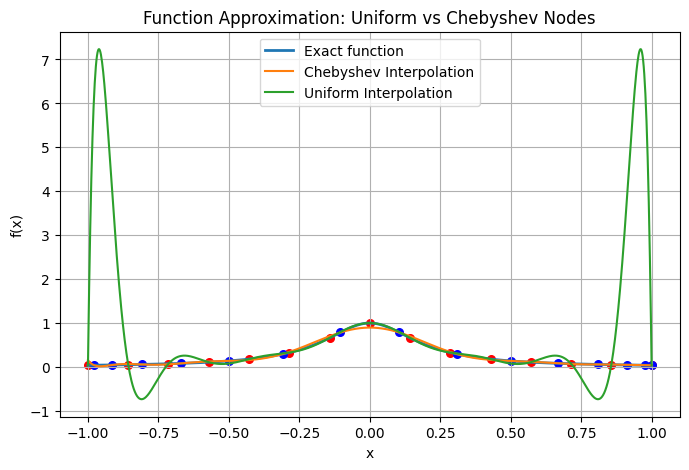

In [10]:
plt.figure(figsize=(8,5))
plt.plot(x_fine, f_fine, label="Exact function",linewidth = 2)
plt.plot(x_fine, f_cheb_interp, label="Chebyshev Interpolation")
plt.plot(x_fine, f_uniform_interp, label="Uniform Interpolation")

plt.scatter(x_uniform, f_uniform, c='red', s=30)
plt.scatter(x_chebyshev, f_chebyshev, c='blue', s=30)

plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function Approximation: Uniform vs Chebyshev Nodes')
plt.grid(True)
plt.show()

In [11]:
## uniform interpolation of the polynomial shows oscillations at the ends

## Comparitive Study

In [12]:
import torch
import torch as nn
import numpy as np
import random
import time

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [14]:
def set_seed(seed=42):
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  np.random.seed(seed)
  random.seed(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

set_seed(42)

In [15]:
CONFIG = {
    "pde": "poisson",

    "device":device,
    "dtype":torch.float32,

    "hidden_layers":4,
    "hidden_units":50,
    "activation":"tanh",

    "optimizer": "adam",

    "adam_lr": 1e-3,
    "adam_epochs":20000,

    "use_lbfgs":True,
    "lbfgs_max_iter": 5000,
    "lbfgs_history_size": 50,

    "collocation_type": "uniform",
    "chebyshev_dd_K": None,

    "x_min":-1.0,
    "x_max":1.0,
    "t_min":0.0,
    "t_max":1.0
}

In [16]:
def uniform_nodes(N,x_min, x_max, device):
  x = torch.linspace(x_min, x_max, N,device=device)
  return x.view(-1,1)

In [17]:
set_seed(42)
def random_nodes(N, x_min, x_max, device):
  x = x_min + (x_max-x_min)*torch.rand(N,device=device)
  return x.view(-1,1)

In [18]:
def chebyshev_nodes(N, x_min, x_max, device):
  i = torch.arange(0,N,1,device=device)
  xi = torch.cos((i*torch.pi)/N)
  x = 0.5 * (x_min+x_max) + 0.5 * (x_max-x_min)*xi

  return x.view(-1,1)

In [19]:
def chebyshev_dd_nodes(N, K, x_min, x_max, device):
  #K domains
  assert N>=K, "N must be greater than K"
  N_sub = N//K
  nodes = []

  dx = (x_max-x_min)/K

  for i in range(K):
    sub_x_min = x_min + i*dx
    sub_x_max = x_min + (i+1)*dx

    x_sub = chebyshev_nodes(N_sub, sub_x_min, sub_x_max, device=device)
    nodes.append(x_sub)
  x = torch.cat(nodes, 0)
  return x

In [20]:
N = 50
K = 8

x_u = uniform_nodes(N, -1.0, 1.0, device)
x_r = random_nodes(N, -1.0, 1.0, device)
x_cheb = chebyshev_nodes(N, -1.0, 1.0, device)
x_cheb_dd = chebyshev_dd_nodes(N, K, -1.0, 1.0, device)

print(f"Uniform nodes shape: {x_u.shape}\nRandom nodes shape: {x_r.shape}\nChebyshev nodes shape: {x_cheb.shape}\nChebyshev domain decomposed nodes shape: {x_cheb_dd.shape}")

Uniform nodes shape: torch.Size([50, 1])
Random nodes shape: torch.Size([50, 1])
Chebyshev nodes shape: torch.Size([50, 1])
Chebyshev domain decomposed nodes shape: torch.Size([48, 1])


In [21]:
import matplotlib.pyplot as plt

def plot_nodes(x, title):
  x_np = x.cpu().numpy().flatten()
  y = torch.zeros_like(x).cpu().numpy().flatten()

  plt.figure(figsize=(10,4))
  plt.scatter(x_np, y, s=10)
  plt.yticks([])
  plt.xlabel("x")
  plt.title(title)
  plt.show()

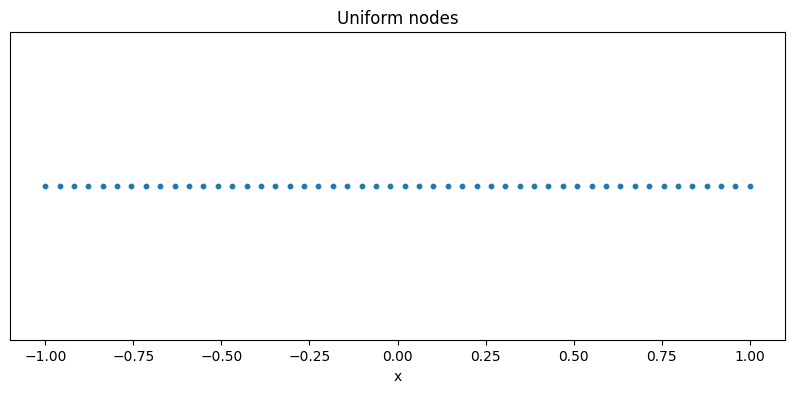

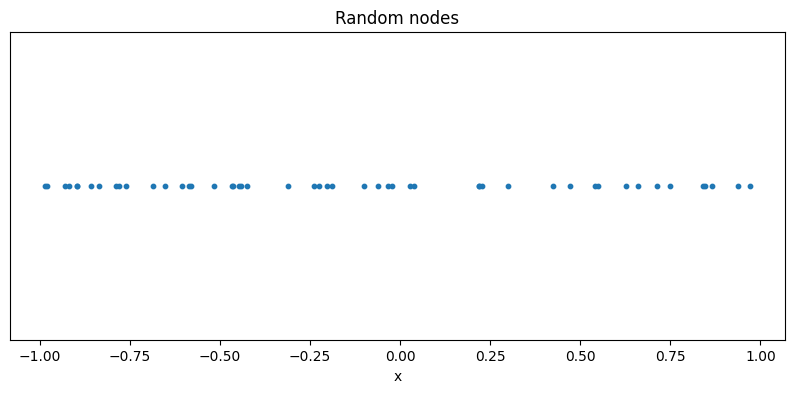

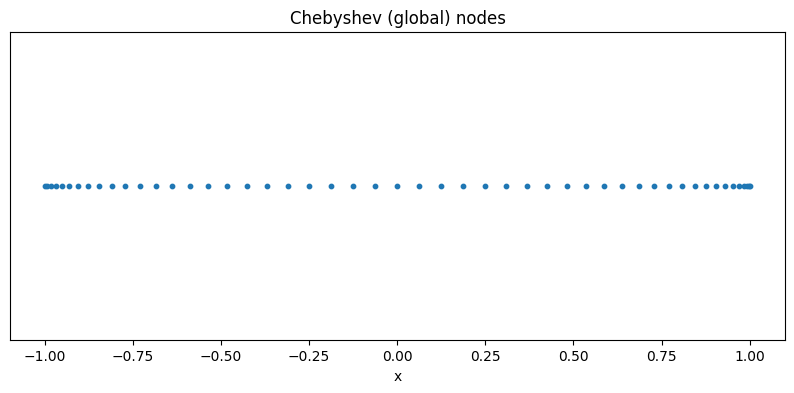

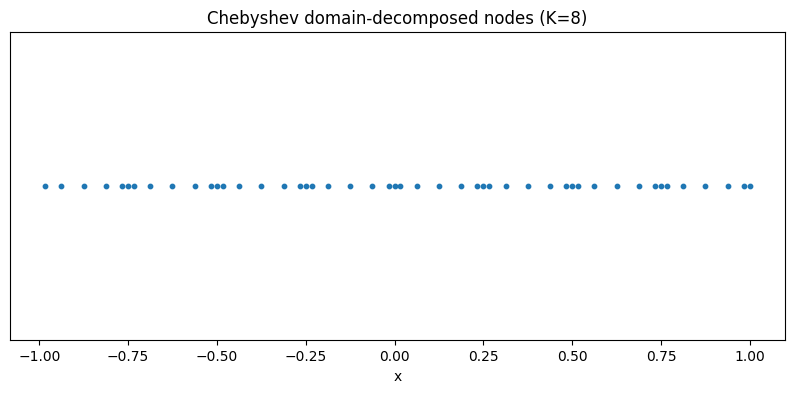

In [22]:
plot_nodes(x_u, "Uniform nodes")
plot_nodes(x_r, "Random nodes")
plot_nodes(x_cheb, "Chebyshev (global) nodes")
plot_nodes(x_cheb_dd, f"Chebyshev domain-decomposed nodes (K={K})")


In [23]:
## we are considering uniform time_stamps as nodes for now
def time_nodes(Nt, t_min, t_max, device):
  t = torch.linspace(t_min, t_max, Nt, device=device)
  return t.view(-1,1)

In [24]:
def burger_collocation_points(x_nodes, t_nodes):
  """
  constructing (t,x) collocation points for burger equation
  x_nodes = (Nx,1)
  t_nodes = (Nt,1)
  """
  T, X = torch.meshgrid(t_nodes.squeeze(),
                        x_nodes.squeeze(),
                        indexing='ij')
  t_f = T.reshape(-1,1)
  x_f = X.reshape(-1,1)
  return t_f, x_f

In [25]:
def poisson_collocation_points(x_nodes):
  return x_nodes

In [26]:
def plot_burger_collocation(t_f, x_f, title):
  plt.figure(figsize=(10,4))
  plt.scatter(t_f.cpu().numpy(), x_f.cpu().numpy(), s=1)
  plt.xlabel('t')
  plt.ylabel('x')
  plt.title(title)
  plt.show()

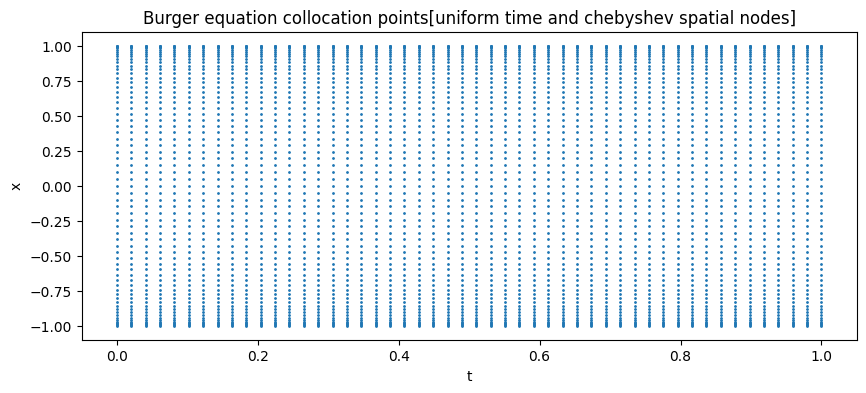

In [27]:
## example plotting
x_c = chebyshev_nodes(64, -1, 1, device)
t_c = time_nodes(50, 0, 1, device)

t_f, x_f = burger_collocation_points(x_c, t_c)
plot_burger_collocation(t_f, x_f, "Burger equation collocation points[uniform time and chebyshev spatial nodes]")

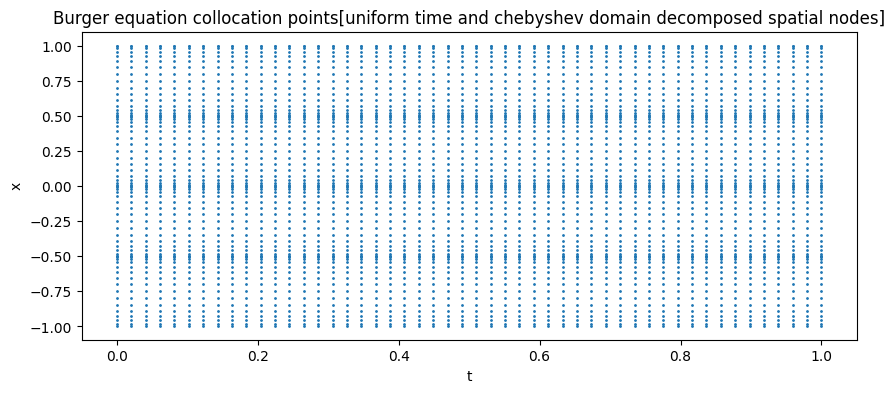

In [28]:
## example plotting
x_c = chebyshev_dd_nodes(64, 4, -1, 1, device)
t_c = time_nodes(50, 0, 1, device)

t_f, x_f = burger_collocation_points(x_c, t_c)
plot_burger_collocation(t_f, x_f, "Burger equation collocation points[uniform time and chebyshev domain decomposed spatial nodes]")

In [29]:
x_c = chebyshev_nodes(128, -1, 1, device)
t_c = time_nodes(50, 0, 1, device)

t_f, x_f = burger_collocation_points(x_c, t_c)

In [30]:
import math
import torch.nn as nn

In [31]:
def get_activation(name):
  if name == "tanh":
    return nn.Tanh()
  elif name == "sin":
    return torch.sin
  else:
    raise ValueError(f"Unkown activation: {name}")

In [32]:
class PINN(nn.Module):
  def __init__(self, input_dim, hidden_units, hidden_layers, activation):
    super().__init__()

    self.input_dim = input_dim
    self.hidden_units = hidden_units
    self.hidden_layers = hidden_layers

    self.activation_name = activation
    self.activation = get_activation(activation)

    layers = []

    #input layer
    layers.append(nn.Linear(input_dim, hidden_units))

    #hidden layers
    for _ in range(hidden_layers-1):
      layers.append(nn.Linear(hidden_units, hidden_units))

    #Output layer
    layers.append(nn.Linear(hidden_units, 1))

    self.layers = nn.ModuleList(layers)
    self.initialize_weights()


  def initialize_weights(self):
    for layer in self.layers:
      if isinstance(layer, nn.Linear):
        nn.init.xavier_normal_(layer.weight)
        nn.init.zeros_(layer.bias)


  def forward(self, *inputs):
    x = torch.cat(inputs, dim=1)
    for layer in self.layers[:-1]:
      x = layer(x)
      x = self.activation(x)
    x = self.layers[-1](x)
    return x

In [33]:
model_poisson = PINN(
    input_dim = 1,
    hidden_units = CONFIG["hidden_units"],
    hidden_layers = CONFIG["hidden_layers"],
    activation = CONFIG["activation"]
).to(CONFIG["device"])

In [34]:
model_burger = PINN(
    input_dim = 2,
    hidden_units = CONFIG["hidden_units"],
    hidden_layers = CONFIG["hidden_layers"],
    activation = CONFIG["activation"]
).to(CONFIG["device"])

In [35]:
## testing whether model is working properly?
t_test = torch.rand(10,1).to(device)
x_test = torch.rand(10,1).to(device)

u_test = model_burger(t_test,x_test)
print(u_test.shape)

torch.Size([10, 1])


We choose the below equation:

$$u(x) = \sin(\pi x), \quad x \in [-1, 1]$$

Then:

$$u_{xx}(x) = -\pi^2 \sin(\pi x)$$

So the Poisson equation is:

$$-u_{xx}(x) = \pi^2 \sin(\pi x)$$

Boundary conditions:

$$u(-1)=0, \quad u(1)=0$$

$$R(x_f) = -u_{xx}(x_f) - f(x_f) = 0$$

In [36]:
## resiudal for collocation points
def poisson_residual(model, x_f):
  """
  compute poisson pde residual
  -u_xx - f(x) = 0
  """

  #ensure x requires gradients
  x_f.requires_grad_(True)

  #forward pass
  u = model(x_f)

  #u_x
  u_x = torch.autograd.grad(
      u,x_f,
      grad_outputs=torch.ones_like(u),
      create_graph=True,
      retain_graph=True
  )[0]

  #u_xx
  u_xx = torch.autograd.grad(
      u_x, x_f,
      grad_outputs=torch.ones_like(u_x),
      retain_graph=True,
      create_graph=True
  )[0]

  # f(x)
  f = (torch.pi**2) * torch.sin(torch.pi*x_f)

  #residual
  residual = -u_xx - f
  return residual

In [37]:
## loss for boundary points/initial conditions
def poisson_boundary_loss(model, device):
  x_b = torch.tensor([[-1.0],[1.0]],device=device)
  u_b = model(x_b)
  residual = (u_b-0)**2
  return torch.mean(residual)

In [38]:
## Loss
def poisson_loss(model, x_f, device):
  res = poisson_residual(model, x_f)
  pde_loss = torch.mean(res**2)
  bc_loss = poisson_boundary_loss(model, device)
  return pde_loss+bc_loss

#Burger Equation
$$f(t_f, x_f) = u_t(t_f, x_f) + u(t_f, x_f)u_x(t_f, x_f) - \nu u_{xx}(t_f, x_f)$$

In [39]:
def burger_residual(model, t_f, x_f, nu):
  """
  compute burgers pde residual
  """
  t_f.requires_grad_(True)
  x_f.requires_grad_(True)

  #forward pass
  u = model(t_f, x_f)

  #u_t
  u_t = torch.autograd.grad(
      u, t_f,
      grad_outputs=torch.ones_like(u),
      create_graph=True,
      retain_graph=True
  )[0]

  #u_x
  u_x = torch.autograd.grad(
      u, x_f,
      grad_outputs=torch.ones_like(u),
      create_graph=True,
      retain_graph=True
  )[0]

  #u_xx
  u_xx = torch.autograd.grad(
      u_x, x_f,
      grad_outputs=torch.ones_like(u_x),
      create_graph=True
  )[0]

  residual = u_t + u * u_x + nu * u_xx
  return residual

In [40]:
def burgers_initial_loss(model, x_i, device):
  t_i = torch.zeros_like(x_i).to(device)
  u_i_pred = model(t_i, x_i)
  u_i_true = -torch.sin(torch.pi * x_i)
  return torch.mean((u_i_pred - u_i_true)**2)

In [41]:
def burgers_boundary_loss(model, t_b, device):
  x_left = -torch.ones_like(t_b).to(device)
  x_right = torch.ones_like(t_b).to(device)

  u_left = model(t_b, x_left)
  u_right = model(t_b,x_right)

  return torch.mean(u_left**2) + torch.mean(u_right**2)

In [42]:
def burger_loss(model, x_f, t_f, x_i, t_b, nu, device):
  res = burger_residual(model, t_f, x_f, nu)
  pde_loss = torch.mean(res**2)

  ic_loss = burgers_initial_loss(model, x_i, device)
  bc_loss = burgers_boundary_loss(model, t_b, device)

  return pde_loss + ic_loss + bc_loss

In [43]:
from tqdm import tqdm

def train_adam(
    model,
    loss_fn,
    optimizer,
    epochs,
    log_every=1000
):
  """
  adam training loop
  """
  loss_history = []
  model.train()

  for epoch in tqdm(range(epochs)):
    optimizer.zero_grad()
    loss = loss_fn()
    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % log_every == 0:
      print(f"Epoch {epoch:06d} | Loss: {loss.item():.6e}")

  return loss_history

In [44]:
# poisson collocation
N_poisson = 15

x_f_poisson = chebyshev_nodes(
    N_poisson,
    CONFIG["x_min"],
    CONFIG["x_max"],
    CONFIG["device"]
)

In [45]:
def poisson_evaluation_grid(nx=1000, device="cpu"):
    x = torch.linspace(-1.0, 1.0, nx, device=device).view(-1, 1)
    return x

$$u_{\text{true}}(x) = \sin(\pi x)$$

In [46]:
def poisson_exact_solution(x):
  return torch.sin(torch.pi * x)

In [47]:
def evaluate_poisson_model(model, x_eval):
  model.eval()
  with torch.no_grad():
    u_pred = model(x_eval)
  return u_pred

$$\|u_{\text{pred}} - u_{\text{true}}\|_{L^2} \approx \sqrt{\text{mean}((u_{\text{pred}} - u_{\text{true}})^2)}$$

In [48]:
def l2_error(u_pred, u_true):
  return torch.sqrt(torch.mean((u_pred-u_true)**2)).item()

In [49]:
def plot_training_loss(
    loss_history,
    title="Training Loss",
    xlabel="Epoch",
    ylabel="Loss"
):
    plt.figure(figsize=(6,4))
    plt.semilogy(loss_history)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()

In [50]:
model_poisson_reduced_lr = model_poisson

In [51]:
optimizer = torch.optim.Adam(
    model_poisson.parameters(),
    lr = CONFIG["adam_lr"]
)

loss_fn_poisson = lambda: poisson_loss(
    model_poisson,
    x_f_poisson,
    CONFIG["device"]
)

adam_loss_poisson = train_adam(
    model = model_poisson,
    loss_fn = loss_fn_poisson,
    optimizer=optimizer,
    epochs = CONFIG["adam_epochs"]
)

  0%|          | 0/20000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
  0%|          | 18/20000 [00:00<05:50, 57.00it/s] 

Epoch 000000 | Loss: 3.821752e+01


  5%|▌         | 1027/20000 [00:06<01:53, 167.05it/s]

Epoch 001000 | Loss: 1.002303e-03


 10%|█         | 2023/20000 [00:12<01:45, 171.01it/s]

...

 90%|█████████ | 18035/20000 [01:46<00:11, 172.36it/s]

Epoch 018000 | Loss: 6.824884e-04


 95%|█████████▌| 19031/20000 [01:52<00:05, 170.18it/s]

Epoch 019000 | Loss: 2.840786e-03


100%|██████████| 20000/20000 [01:58<00:00, 169.08it/s]


In [52]:
#build evaluation grid
x_eval = poisson_evaluation_grid(device=CONFIG["device"])

#true solution
u_true = poisson_exact_solution(x_eval)

#predicted solution
u_pred = evaluate_poisson_model(model_poisson, x_eval)

#error
error_poisson = l2_error(u_pred, u_true)
print("Poisson L2 error with calculated solution: ", error_poisson)

Poisson L2 error with calculated solution:  0.005679374560713768


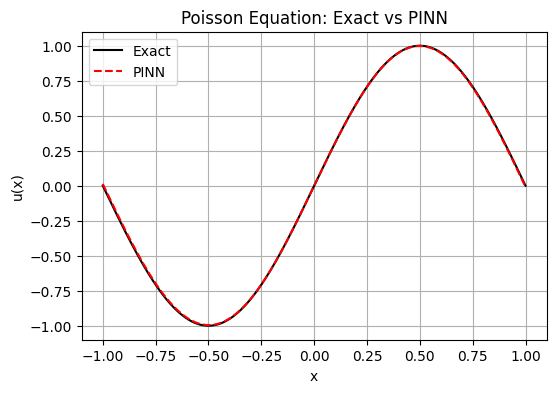

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(x_eval.cpu(), u_true.cpu(), 'k-', label="Exact")
plt.plot(x_eval.cpu(), u_pred.cpu(), 'r--', label="PINN")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.title("Poisson Equation: Exact vs PINN")
plt.grid(True)
plt.show()

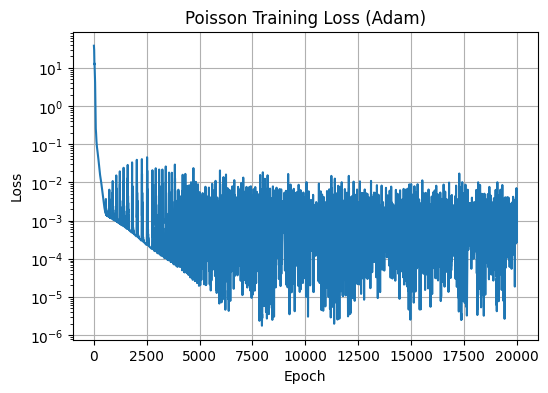

In [54]:
plot_training_loss(
    adam_loss_poisson,
    title="Poisson Training Loss (Adam)"
)

In [55]:
optimizer_reduced_lr = torch.optim.Adam(
    model_poisson_reduced_lr.parameters(),
    lr = 1e-5
)

loss_fn_poisson = lambda: poisson_loss(
    model_poisson_reduced_lr,
    x_f_poisson,
    CONFIG["device"]
)

adam_loss_poisson_reduced_lr = train_adam(
    model = model_poisson_reduced_lr,
    loss_fn = loss_fn_poisson,
    optimizer=optimizer_reduced_lr,
    epochs = CONFIG["adam_epochs"]
)

  0%|          | 35/20000 [00:00<01:56, 170.90it/s]

Epoch 000000 | Loss: 1.756266e-03


  5%|▌         | 1026/20000 [00:06<01:54, 166.24it/s]

Epoch 001000 | Loss: 8.284562e-07


 10%|█         | 2030/20000 [00:12<01:47, 167.29it/s]

...

 90%|█████████ | 18022/20000 [01:46<00:11, 165.09it/s]

Epoch 018000 | Loss: 6.079408e-08


 95%|█████████▌| 19022/20000 [01:52<00:05, 168.42it/s]

Epoch 019000 | Loss: 4.981633e-08


100%|██████████| 20000/20000 [01:58<00:00, 169.31it/s]


In [56]:
u_pred_rlr = evaluate_poisson_model(model_poisson_reduced_lr, x_eval)
error_poisson_rlr = l2_error(u_pred_rlr, u_true)
print("Poisson L2 error with calculated solution(reduced lr): ", error_poisson_rlr)

Poisson L2 error with calculated solution(reduced lr):  0.000241511341300793


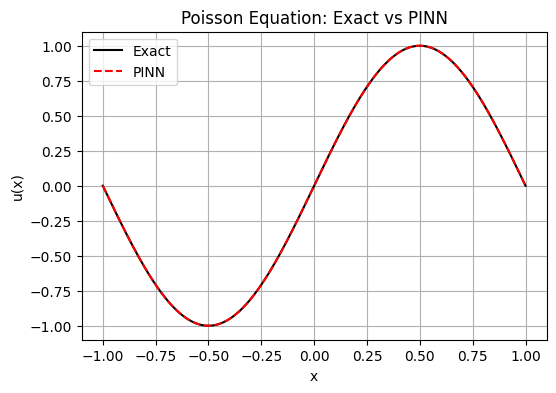

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(x_eval.cpu(), u_true.cpu(), 'k-', label="Exact")
plt.plot(x_eval.cpu(), u_pred_rlr.cpu(), 'r--', label="PINN")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.title("Poisson Equation: Exact vs PINN")
plt.grid(True)
plt.show()

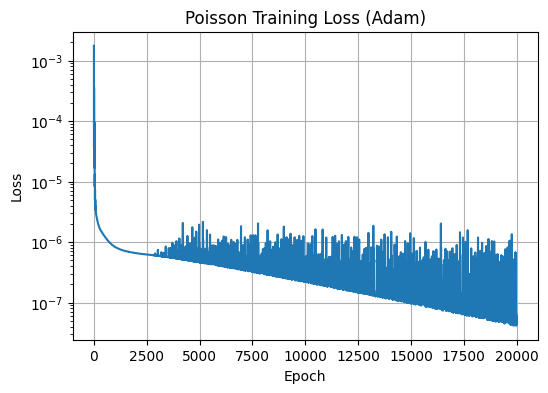

In [58]:
plot_training_loss(
    adam_loss_poisson_reduced_lr,
    title="Poisson Training Loss (Adam)"
)

# Lets perform different activations and differnt collocation methods and perform a comparitive study

In [59]:
def poisson_collocation_factory(N, CONFIG):
    if CONFIG["collocation_type"] == "uniform":
        return uniform_nodes(N, CONFIG["x_min"], CONFIG["x_max"], CONFIG["device"])

    elif CONFIG["collocation_type"] == "random":
        return random_nodes(N, CONFIG["x_min"], CONFIG["x_max"], CONFIG["device"])

    elif CONFIG["collocation_type"] == "chebyshev":
        return chebyshev_nodes(N, CONFIG["x_min"], CONFIG["x_max"], CONFIG["device"])

    elif CONFIG["collocation_type"] == "chebyshev_dd":
        return chebyshev_dd_nodes(
            N,
            CONFIG["chebyshev_dd_K"],
            CONFIG["x_min"],
            CONFIG["x_max"],
            CONFIG["device"]
        )

    else:
        raise ValueError("Unknown collocation type")

In [60]:
def run_poisson_experiment(N, CONFIG):
    set_seed(42)

    # 1. Build model
    model = PINN(
        input_dim=1,
        hidden_units=CONFIG["hidden_units"],
        hidden_layers=CONFIG["hidden_layers"],
        activation=CONFIG["activation"]
    ).to(CONFIG["device"])

    # 2. Collocation points
    x_f = poisson_collocation_factory(N, CONFIG)

    # 3. Optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CONFIG["adam_lr"]
    )

    # 4. Training
    loss_fn = lambda: poisson_loss(model, x_f, CONFIG["device"])

    loss_history = train_adam(
        model=model,
        loss_fn=loss_fn,
        optimizer=optimizer,
        epochs=CONFIG["adam_epochs"],
        log_every=2000
    )

    # 5. Evaluation
    x_eval = poisson_evaluation_grid(device=CONFIG["device"])
    u_true = poisson_exact_solution(x_eval)
    u_pred = evaluate_poisson_model(model, x_eval)

    l2_err = l2_error(u_pred, u_true)

    # 6. Store result
    result = {
        "pde": "poisson",
        "collocation": CONFIG["collocation_type"],
        "activation": CONFIG["activation"],
        "N": N,
        "l2_error": l2_err,
        "loss_history": loss_history
    }

    return result

In [61]:
all_results = []

N_list = [20, 40, 80, 160, 320, 640]
activations = ["tanh", "sin"]
collocations = ["uniform", "random", "chebyshev","chebyshev_dd"]

for activation in activations:
    CONFIG["activation"] = activation

    for colloc in collocations:
        CONFIG["collocation_type"] = colloc
        if colloc == "chebyshev_dd":
            CONFIG["chebyshev_dd_K"] = 8
        else:
            CONFIG["chebyshev_dd_K"] = None

        for N in N_list:
            print(f"\nRunning Poisson | act={activation}, colloc={colloc}, N={N}")
            result = run_poisson_experiment(N, CONFIG)
            all_results.append(result)


Running Poisson | act=tanh, colloc=uniform, N=20


  0%|          | 16/20000 [00:00<02:08, 155.64it/s]

Epoch 000000 | Loss: 4.652988e+01


 10%|█         | 2030/20000 [00:12<01:45, 170.92it/s]

Epoch 002000 | Loss: 1.089181e-04


...

 80%|████████  | 16030/20000 [01:39<00:24, 163.52it/s]

Epoch 016000 | Loss: 1.170180e-05


 90%|█████████ | 18025/20000 [01:52<00:12, 163.92it/s]

Epoch 018000 | Loss: 2.959003e-05


100%|██████████| 20000/20000 [02:04<00:00, 160.72it/s]


In [62]:
def plot_poisson_convergence(all_results, activation):
    plt.figure(figsize=(16,10))

    for colloc in set(r["collocation"] for r in all_results):
        Ns = []
        errors = []

        for r in all_results:
            if r["pde"] == "poisson" and \
               r["activation"] == activation and \
               r["collocation"] == colloc:
                Ns.append(r["N"])
                errors.append(r["l2_error"])

        Ns, errors = zip(*sorted(zip(Ns, errors)))
        plt.loglog(Ns, errors, marker='o', label=colloc)

    plt.xlabel("Number of collocation points (N)")
    plt.ylabel("L2 Error")
    plt.title(f"Poisson Convergence ({activation})")
    plt.grid(True, which="both")
    plt.legend()
    plt.show()


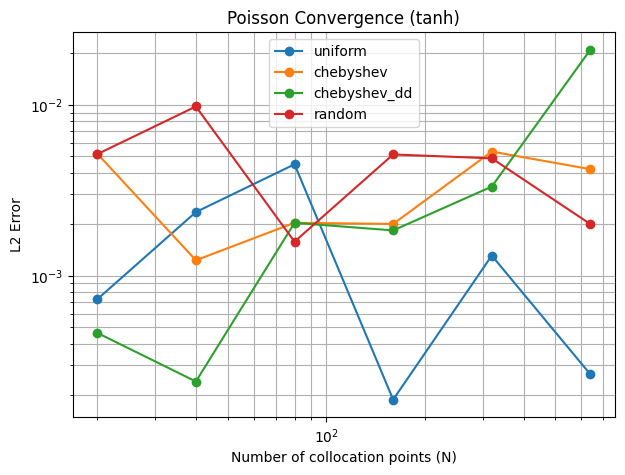

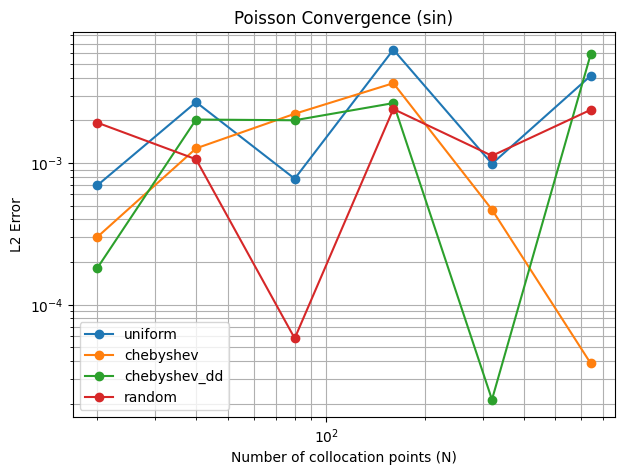

In [63]:
plot_poisson_convergence(all_results, activation="tanh")
plot_poisson_convergence(all_results, activation="sin")

In [69]:
CONFIG.update({
    "activation": "sin",
    "collocation_type": "chebyshev_dd",
    "chebyshev_dd_K": 8,
    "optimizer": "adam + lbfgs",
    "adam_lr": 1e-3,
    "adam_epochs": 20000,
    "lbfgs_max_iter": 5000,
    "lbfgs_history_size": 50
})

In [77]:
found = False

for r in all_results:
    if (
        r["activation"] == "sin"
        and r["collocation"] == "chebyshev_dd"
        and r["N"] == 320
    ):
        print("found")
        print("L2 error:", r["l2_error"])
        found = True

if not found:
    print("not found")

found
L2 error: 2.131157998519484e-05


In [78]:
print(f"{'Activation':<10} {'Collocation':<15} {'N':<6} {'L2 Error':<12}")
print("-" * 50)

for r in all_results:
    print(
        f"{r['activation']:<10} "
        f"{r['collocation']:<15} "
        f"{r['N']:<6} "
        f"{r['l2_error']:.6e}"
    )


Activation Collocation     N      L2 Error    
--------------------------------------------------
tanh       uniform         20     7.273176e-04
tanh       uniform         40     2.355480e-03
tanh       uniform         80     4.482859e-03
tanh       uniform         160    1.882960e-04
tanh       uniform         320    1.310874e-03
tanh       uniform         640    2.643653e-04
tanh       random          20     5.137464e-03
tanh       random          40     9.766308e-03
tanh       random          80     1.581176e-03
tanh       random          160    5.119341e-03
tanh       random          320    4.857409e-03
tanh       random          640    2.001783e-03
tanh       chebyshev       20     5.176097e-03
tanh       chebyshev       40     1.230345e-03
tanh       chebyshev       80     2.038935e-03
tanh       chebyshev       160    2.008108e-03
tanh       chebyshev       320    5.320384e-03
tanh       chebyshev       640    4.196557e-03
tanh       chebyshev_dd    20     4.627707e-04
tanh     

In [80]:
import pandas as pd

df = pd.DataFrame(all_results)
df = df[["activation", "collocation", "N", "l2_error"]]

In [81]:
df_sorted = df.sort_values(by="l2_error")
print(df_sorted)

   activation   collocation    N  l2_error
46        sin  chebyshev_dd  320  0.000021
41        sin     chebyshev  640  0.000039
32        sin        random   80  0.000058
42        sin  chebyshev_dd   20  0.000182
3        tanh       uniform  160  0.000188
19       tanh  chebyshev_dd   40  0.000240
5        tanh       uniform  640  0.000264
36        sin     chebyshev   20  0.000301
18       tanh  chebyshev_dd   20  0.000463
40        sin     chebyshev  320  0.000469
24        sin       uniform   20  0.000697
0        tanh       uniform   20  0.000727
26        sin       uniform   80  0.000776
28        sin       uniform  320  0.000989
31        sin        random   40  0.001064
34        sin        random  320  0.001126
13       tanh     chebyshev   40  0.001230
37        sin     chebyshev   40  0.001271
4        tanh       uniform  320  0.001311
8        tanh        random   80  0.001581
21       tanh  chebyshev_dd  160  0.001840
30        sin        random   20  0.001929
11       ta

In [82]:
pd.set_option("display.float_format", "{:.2e}".format)
df_sorted

,activation,collocation,N,l2_error
46,sin,chebyshev_dd,320,2.13e-05
41,sin,chebyshev,640,3.85e-05
32,sin,random,80,5.78e-05
42,sin,chebyshev_dd,20,1.82e-04
3,tanh,uniform,160,1.88e-04
19,tanh,chebyshev_dd,40,2.40e-04
5,tanh,uniform,640,2.64e-04
36,sin,chebyshev,20,3.01e-04
18,tanh,chebyshev_dd,20,4.63e-04
40,sin,chebyshev,320,4.69e-04


In [83]:
best_per_activation = df.loc[df.groupby("activation")["l2_error"].idxmin()]
print(best_per_activation)

   activation   collocation    N  l2_error
46        sin  chebyshev_dd  320  2.13e-05
3        tanh       uniform  160  1.88e-04


In [84]:
best_overall = df.loc[df["l2_error"].idxmin()]
print(best_overall)

activation              sin
collocation    chebyshev_dd
N                       320
l2_error           2.13e-05
Name: 46, dtype: object


In [70]:
N = 320

x_f = chebyshev_dd_nodes(
    N=N,
    K=CONFIG["chebyshev_dd_K"],
    x_min=CONFIG["x_min"],
    x_max=CONFIG["x_max"],
    device=CONFIG["device"]
)

In [71]:
set_seed(42)

model_poisson = PINN(
    input_dim=1,
    hidden_units=CONFIG["hidden_units"],
    hidden_layers=CONFIG["hidden_layers"],
    activation=CONFIG["activation"]
).to(CONFIG["device"])

In [72]:
optimizer_lbfgs = torch.optim.LBFGS(
    model_poisson.parameters(),
    max_iter=CONFIG["lbfgs_max_iter"],
    history_size=CONFIG["lbfgs_history_size"],
    tolerance_grad=1e-9,
    tolerance_change=1e-9,
    line_search_fn="strong_wolfe"
)

def lbfgs_closure():
    optimizer_lbfgs.zero_grad()
    loss = poisson_loss(
        model_poisson,
        x_f,
        CONFIG["device"]
    )
    loss.backward()
    return loss

print("Starting L-BFGS refinement...")
optimizer_lbfgs.step(lbfgs_closure)
print("L-BFGS finished.")

Starting L-BFGS refinement...
L-BFGS finished.


In [73]:
x_eval = poisson_evaluation_grid(device=CONFIG["device"])
u_true = poisson_exact_solution(x_eval)

model_poisson.eval()
with torch.no_grad():
    u_pred = model_poisson(x_eval)

error_lbfgs = l2_error(u_pred, u_true)
print("Poisson L2 error (sin + chebyshev-DD + L-BFGS):", error_lbfgs)

Poisson L2 error (sin + chebyshev-DD + L-BFGS): 4.898189217783511e-05


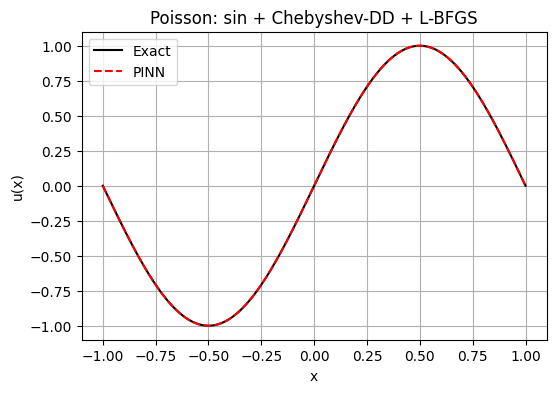

In [74]:
plt.figure(figsize=(6,4))
plt.plot(x_eval.cpu(), u_true.cpu(), 'k-', label="Exact")
plt.plot(x_eval.cpu(), u_pred.cpu(), 'r--', label="PINN")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.title("Poisson: sin + Chebyshev-DD + L-BFGS")
plt.grid(True)
plt.show()